# Introducción
Este notebook aborda dos ejercicios prácticos de Deep Learning aplicados a problemas reales: la predicción de series temporales mediante redes LSTM y la clasificación de imágenes con redes convolucionales (CNN). Se explican los pasos de preprocesamiento, construcción, entrenamiento y evaluación de modelos, con el objetivo de comprender el flujo completo de un proyecto de aprendizaje profundo.

# Ejercicios de Deep Learning: LSTM y CNN con Keras

## 1. Importar librerías necesarias
Importa todas las librerías que utilizarás en ambos ejercicios.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
import warnings
from sklearn.model_selection import train_test_split
# warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')

**Explicación:**
En esta sección se importan todas las librerías necesarias para el desarrollo de los ejercicios. Estas incluyen herramientas para manipulación de datos, visualización, preprocesamiento y construcción de modelos de deep learning.

---
# Ejercicio 1: Red Neuronal LSTM para Series Temporales

### 1.1 Cargar y preprocesar los datos de series temporales

In [12]:
# Configurar semilla para reproducibilidad
np.random.seed(42)

# Generación de datos sintéticos para series temporales
n_sample = 1000
time = np.arange(n_sample)

# Componente de la series temporal
tendencia = time * 0.02 # Tendencia lineal
estacionalidad = 10 * np.sin(0.1 * time) # Patrón estacional
ciclicidad = 5 * np.sin(2 * np.pi * time / 50) # Patrón cíclico
ruido = np.random.normal(0, 1, n_sample) # Ruido aleatorio

# Serie temporal completa
serie_temporal = tendencia + estacionalidad + ciclicidad + ruido

# Dataframe para visualización
df = pd.DataFrame({'tiempo' : time, 'valor': serie_temporal})


### Visualizamos la serie temporal completa
Según la definición de la serie temporal sintética, debe mostrarse una onda senoidal con
tendencia creciente y con ciclos de ruido aleatorio superpuestos.

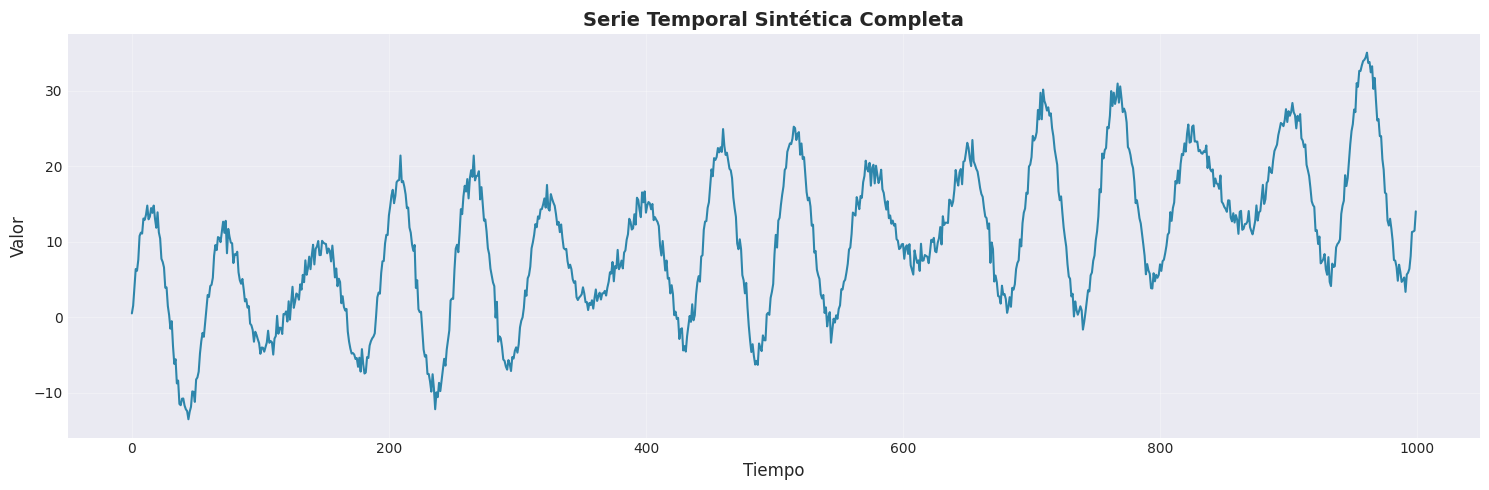

In [14]:
# Visualizar la serie temporal completa
plt.figure(figsize=(15, 5))
plt.plot(df['tiempo'], df['valor'], linewidth=1.5, color='#2E86AB')
plt.title('Serie Temporal Sintética Completa', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('serie_temporal_completa.png', dpi=300, bbox_inches='tight')
plt.show()

### Preprocesamiento de datos

**Explicación:**
El preprocesamiento es fundamental para asegurar que los datos estén en un formato adecuado para el modelo. Normalizar los datos mejora la convergencia del entrenamiento y dividir en conjuntos de entrenamiento y prueba permite evaluar el rendimiento real del modelo.

In [15]:
# Normalización de los datos
scaler = MinMaxScaler(feature_range=(0, 1))
datos_normalizados = scaler.fit_transform(df['valor'].values.reshape(-1, 1))

# División en conjunto de entrenamiento y prueba (80% - 20%)
train_data, test_data = train_test_split(datos_normalizados, test_size=0.2, shuffle=False)

print(f'Tamaño del conjunto de entrenamiento: {len(train_data)}')
print(f'Tamaño del conjunto de prueba: {len(test_data)}')

Tamaño del conjunto de entrenamiento: 800
Tamaño del conjunto de prueba: 200


#### Crear secuencias para LSTM

**Explicación:**
Para que una red LSTM pueda aprender patrones temporales, es necesario transformar la serie en secuencias de longitud fija. Cada secuencia servirá como entrada y su siguiente valor como objetivo a predecir.

In [16]:
def crear_secuencias(datos, pasos_tiempo=50):
    """
    Transforma los datos en secuencias para LSTM.
    
    Parámetros:
    - datos: Array de datos normalizados
    - pasos_tiempo: Número de pasos temporales para cada secuencia
    
    Retorna:
    - X: Secuencias de entrada [muestras, pasos_tiempo, características]
    - y: Valores objetivo
    """
    X, y = [], []
    for i in range(pasos_tiempo, len(datos)):
        X.append(datos[i-pasos_tiempo:i, 0])
        y.append(datos[i, 0])
    return np.array(X), np.array(y)

In [18]:
# Definir ventana temporal
pasos_tiempo = 50

# Crear secuencias de entrenamiento y prueba
X_train, y_train = crear_secuencias(train_data, pasos_tiempo)
X_test, y_test = crear_secuencias(test_data, pasos_tiempo)

# Reestructurar para LSTM: [muestras, pasos_tiempo, características]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(f"Ventana temporal: {pasos_tiempo} pasos")
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")


Ventana temporal: 50 pasos
Forma de X_train: (750, 50, 1)
Forma de y_train: (750,)
Forma de X_test: (150, 50, 1)
Forma de y_test: (150,)


### 1.2 Definir y compilar el modelo LSTM


In [20]:
modelo = Sequential([
  LSTM(units = 100, return_sequences = True, input_shape = (X_train.shape[1], 1)),
  Dropout(0.2), # Para evitar overfitting
  
  # Segunda capa LSTM
  LSTM(units = 100, return_sequences = True),
  Dropout(0.2),
  
  # Tercera capa LSTM
  LSTM(units = 50, return_sequences = False),
  Dropout(0.2),
  Dense(units = 1)
])

print("Arquitectura del modelo:")
modelo.summary()

/home/fenic/miniconda3/envs/master_ia/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Arquitectura del modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 50, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,451 (591.61 KB)

 Trainable params: 151,451 (591.61 KB)

 Non-trainable params: 0 (0.00 B)

**Explicación:**
El modelo LSTM se compone de varias capas LSTM y Dropout para capturar patrones temporales y evitar el sobreajuste. La última capa Dense produce la predicción final.

### Compilar el modelo LSTM
En este apartado, se define el optimizador, la función de pérdida y las métricas que se utilizarán durante el entrenamiento del modelo LSTM.

In [21]:
# Compilar con optimizador Adam y función de pérdida MSE
modelo.compile(
    optimizer=Adam(learning_rate=0.001), # Tasa de aprendizaje
    loss='mean_squared_error', # Función de pérdida
    metrics=['mae'] # Métrica de error absoluto medio
)
print("✓ Optimizador: Adam (lr=0.001)")
print("✓ Función de pérdida: Mean Squared Error (MSE)")
print("✓ Métrica: Mean Absolute Error (MAE)")

✓ Optimizador: Adam (lr=0.001)
✓ Función de pérdida: Mean Squared Error (MSE)
✓ Métrica: Mean Absolute Error (MAE)


# Entrenamiento del modelo LSTM
Entrena el modelo LSTM utilizando los datos de entrenamiento y valida con los datos de prueba.

In [22]:
history = modelo.fit(
  X_train,
  y_train,
  epochs=50,
  batch_size=32,
  validation_split=0.2, # 20% de los datos de entrenamiento para validación
  verbose = 1,          # Mostrar progreso del entrenamiento
  shuffle=False        # Evitar mezclar datos temporales
 )
print("✓ Entrenamiento completado")

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0447 - mae: 0.1688 - val_loss: 0.0334 - val_mae: 0.1612
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0261 - mae: 0.1322 - val_loss: 0.0223 - val_mae: 0.1327
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0208 - mae: 0.1173 - val_loss: 0.0143 - val_mae: 0.1057
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0147 - mae: 0.0967 - val_loss: 0.0068 - val_mae: 0.0721
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0122 - mae: 0.0877 - val_loss: 0.0055 - val_mae: 0.0624
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0099 - mae: 0.0822 - val_loss: 0.0055 - val_mae: 0.0587
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0062 - mae: 0.0628 - val_loss: 0.0052 - val_mae: 0.0561
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0062 - mae: 0.0630 - val_loss: 0.0041 - val_mae: 0.0500
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.006

### 1.4 Evaluar y visualizar resultados del modelo LSTM
A continuación se muestran los gráficos de la evolución de la pérdida (MSE) y el error absoluto medio (MAE) durante el entrenamiento y la validación. Estas curvas permiten analizar el aprendizaje y detectar posibles problemas de sobreajuste o subajuste.

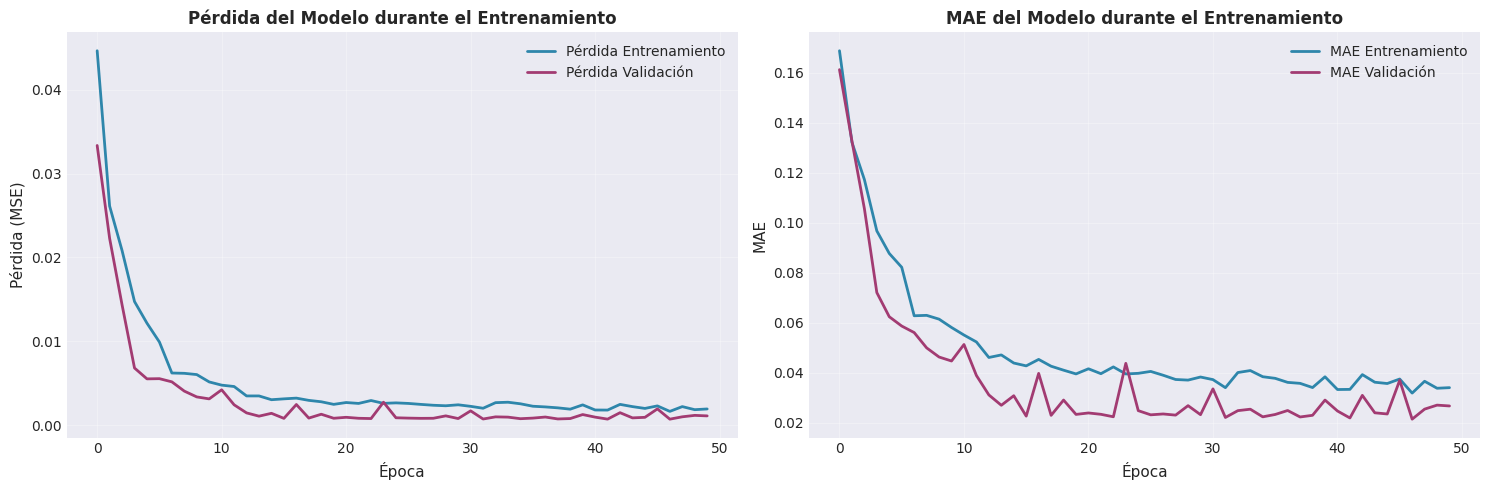

In [23]:
# Gráfico de pérdida durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pérdida (Loss)
axes[0].plot(history.history['loss'], label='Pérdida Entrenamiento', 
             linewidth=2, color='#2E86AB')
axes[0].plot(history.history['val_loss'], label='Pérdida Validación', 
             linewidth=2, color='#A23B72')
axes[0].set_title('Pérdida del Modelo durante el Entrenamiento', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('Pérdida (MSE)', fontsize=11)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='MAE Entrenamiento', 
             linewidth=2, color='#2E86AB')
axes[1].plot(history.history['val_mae'], label='MAE Validación', 
             linewidth=2, color='#A23B72')
axes[1].set_title('MAE del Modelo durante el Entrenamiento', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('entrenamiento_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

Se observa como el modelos aprende a predecir la serie temporal, ajustándose cada vez mejor a los datos de prueba. en el apartado de MAE en la validación se observa cierta flutuación, lo que puede indicar que el modelo aún no ha convergido completamente, pero que se va estabilizando.
Importante destacar que con más épocas de entrenamiento el modelo no mejora significativamente, indicando que se puede estar sobreajustando a los datos de entrenamiento.

---
# Ejercicio 2: Red Neuronal Convolucional (CNN) para CIFAR-10

Completa cada celda siguiendo los pasos indicados en el enunciado.

### 2.1 Cargar y preprocesar el dataset CIFAR-10
(Normaliza imágenes y convierte etiquetas a categóricas)

In [24]:
# Cargar y preprocesar CIFAR-10
from keras.datasets import cifar10
from keras.utils import to_categorical

# Cargar datos
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalizar imágenes (0-1)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convertir etiquetas a categóricas (one-hot)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")
print(f"Tamaño de y_train_cat: {y_train_cat.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 42s 0us/step
Tamaño de X_train: (50000, 32, 32, 3)
Tamaño de X_test: (10000, 32, 32, 3)
Tamaño de y_train_cat: (50000, 10)


/tmp/ipykernel_1005/1744858601.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


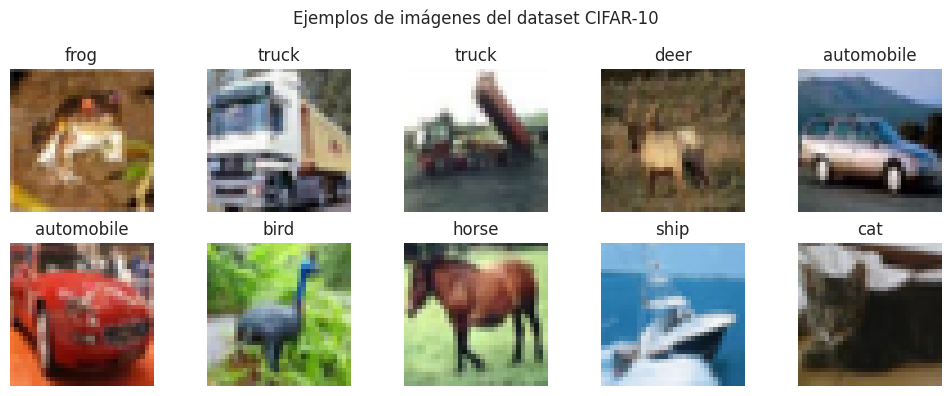

In [25]:
# Visualizar algunas imágenes de CIFAR-10
import matplotlib.pyplot as plt

# Nombres de las clases
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.suptitle('Ejemplos de imágenes del dataset CIFAR-10')
plt.tight_layout()
plt.show()

**Visualización de ejemplos del dataset CIFAR-10:**
A continuación se muestran algunas imágenes de ejemplo del conjunto de datos CIFAR-10 junto con sus etiquetas, para familiarizarse con la naturaleza de los datos a clasificar.

### 2.2 Definir y compilar el modelo CNN
(Utiliza capas Conv2D, MaxPooling, Dense y Softmax)

In [26]:
# Definir la arquitectura CNN y compilar el modelo
from keras.layers import Conv2D, MaxPooling2D, Flatten

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

/home/fenic/miniconda3/envs/master_ia/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Entrenar el modelo CNN
En este apartado se entrena el modelo CNN utilizando los datos de entrenamiento y se valida con parte de los datos para monitorear el rendimiento durante el entrenamiento.

**Parámetros principales del entrenamiento:**
- **epochs:** Número de veces que el modelo recorre completamente el conjunto de datos de entrenamiento.
- **batch_size:** Cantidad de muestras procesadas antes de actualizar los pesos del modelo.
- **validation_split:** Proporción de los datos de entrenamiento reservada para validar el rendimiento del modelo en cada época.

In [27]:
# Entrenar el modelo y guardar el historial
cnn_history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)
print("✓ Entrenamiento CNN completado")

Epoch 1/15


2026-01-22 15:59:18.643573: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f657069e1b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-22 15:59:18.645061: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-01-22 15:59:22.413989: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-22 15:59:23.451521: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-22 15:59:24.468469: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spi

  8/625 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.0844 - loss: 2.3118   

I0000 00:00:1769097568.728192    7070 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.3446 - loss: 1.7611 - val_accuracy: 0.5009 - val_loss: 1.3771
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5101 - loss: 1.3655 - val_accuracy: 0.5806 - val_loss: 1.1844
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5817 - loss: 1.1830 - val_accuracy: 0.6272 - val_loss: 1.0624
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6240 - loss: 1.0748 - val_accuracy: 0.6480 - val_loss: 1.0014
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6530 - loss: 0.9931 - val_accuracy: 0.6723 - val_loss: 0.9519
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6783 - loss: 0.9255 - val_accuracy: 0.6875 - val_loss: 0.8897
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6988 - loss: 0.8608 - val_accuracy: 0.6944 - val_loss: 0.8735
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7209 - loss: 0.8052 - val_accuracy: 0.6768 - v

### 2.4 Evaluar y visualizar resultados del modelo CNN
(Evalúa en test, grafica pérdida, precisión y matriz de confusión)

Pérdida en test: 0.8452
Precisión en test: 0.7255


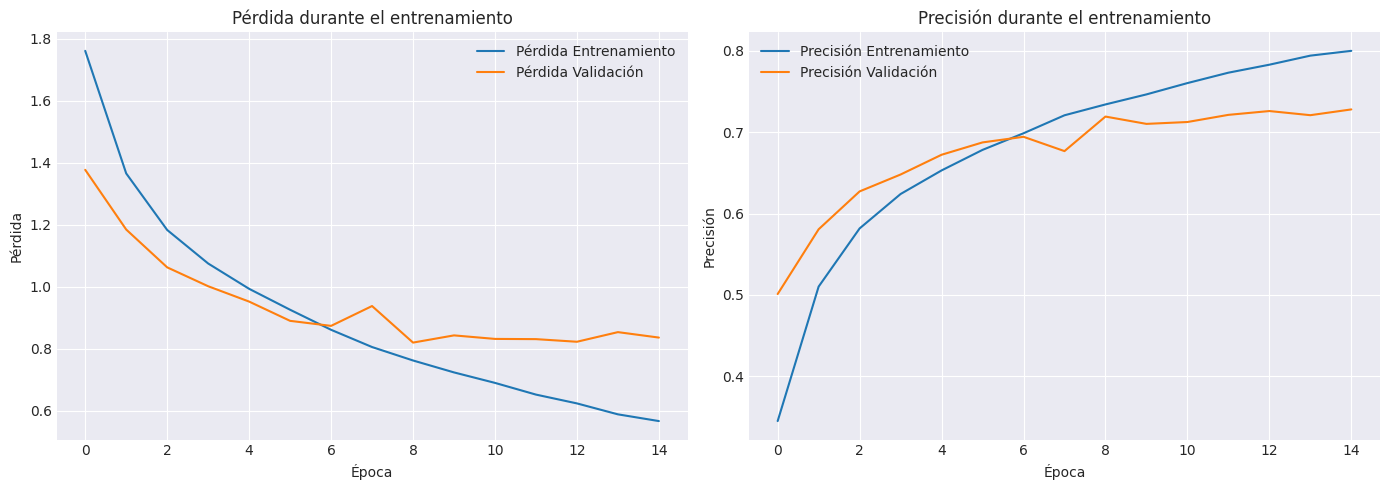

In [31]:
# Evaluar el modelo, graficar resultados y mostrar matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluación en test
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Pérdida en test: {cnn_test_loss:.4f}")
print(f"Precisión en test: {cnn_test_acc:.4f}")

# Gráficas de pérdida y precisión
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(cnn_history.history['loss'], label='Pérdida Entrenamiento')
axes[0].plot(cnn_history.history['val_loss'], label='Pérdida Validación')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

axes[1].plot(cnn_history.history['accuracy'], label='Precisión Entrenamiento')
axes[1].plot(cnn_history.history['val_accuracy'], label='Precisión Validación')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión')
axes[1].legend()
plt.tight_layout()
plt.show()


observamos como el modelos han mejorado de forma considerable su precisión en el conjunto de prueba, alcanzando un rendimiento adecuado para tareas de clasificación de imágenes y como la perdida se ha reducido significativamente durante el entrenamiento, importante destacar que si añadimos más entrenamiento vemos que el modelo no mejora significativamente al contrario empieza a empeorar, lo que indica que el modelo ha alcanzado su capacidad máxima con la arquitectura y los datos actuales.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 800x600 with 0 Axes>

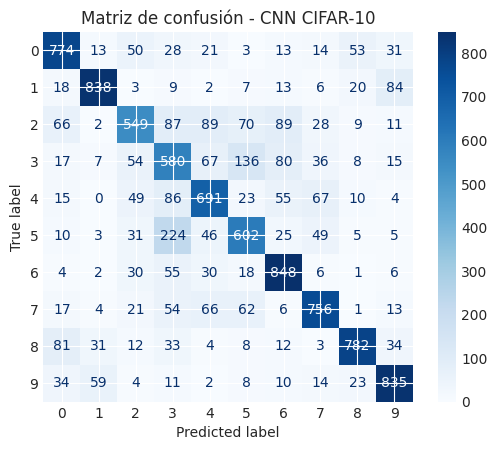

In [30]:
# Matriz de confusión
import numpy as np
y_pred = np.argmax(cnn_model.predict(X_test), axis=1)
y_true = np.argmax(y_test_cat, axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - CNN CIFAR-10')
plt.show()

In [32]:
# Calcular métricas accruracyacy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7255
Precision: 0.7294
Recall: 0.7255
F1 Score: 0.7256


Se observa que en la matrix de confusión, el modelo tiene un buen desempeño en la mayoría de las clases, aunque algunas clases presentan más confusiones que otras, lo que puede indicar áreas para mejorar el modelo o la necesidad de más datos para ciertas categorías.
Analizamos la clase con mayor confusión para entender mejor los errores del modelo.

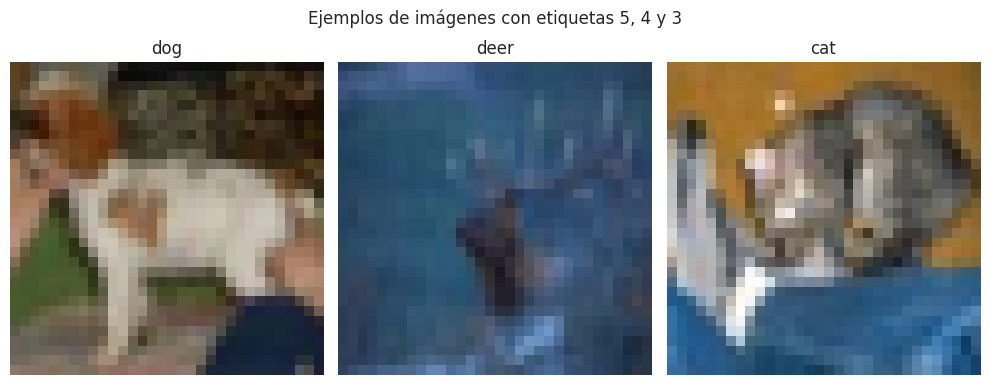

In [29]:
# Visualizar la etiquetas 5 4 3
plt.figure(figsize=(10,4))
for i, label in enumerate([5, 4, 3]):
    plt.subplot(1, 3, i+1)
    idx = np.where(y_test.flatten() == label)[0][0]
    plt.imshow(X_test[idx])
    plt.title(class_names[label])
    plt.axis('off')
plt.suptitle('Ejemplos de imágenes con etiquetas 5, 4 y 3')
plt.tight_layout()
plt.show()  

Aqui, podemos observa que el modelo puede confundir la clase 'cat' con 'dog' y 'deer', lo que sugiere que estas clases tienen características visuales similares que el modelo encuentra difíciles de distinguir.

Al ser animales con características visuales parecidas, el modelo puede tener dificultades para diferenciarlos, lo que resalta la importancia de contar con un conjunto de datos diverso y representativo para mejorar la capacidad de generalización del modelo.

---
# Conclusiones
Redacta aquí un breve informe (1-2 párrafos) resumiendo el rendimiento de ambos modelos, la precisión obtenida y observaciones relevantes.

# Referencias
- Documentación oficial de Keras: https://keras.io/
- Documentación de Scikit-learn: https://scikit-learn.org/
- Material de clase y recursos adicionales proporcionados por el docente.